# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Afifa Nur Mila
- **Email:** mc200d5x2075@student.devacademy.id
- **ID Dicoding:** MC200D5X2075

*E-Commerce Public Dataset* adalah dataset yang berisi terkait data e-commerce yang memiliki beberapa tabel seperti:
- customers_dataset
- geolocation_dataset
- order_items_dataset
- order_payments_dataset
- order_reviews_dataset
- orders_dataset
- product_category_name_translation
- products_dataset
- sellers_dataset

Dalam proses analisis data, kita perlu mengetahui variabel-variabel apa saja yang terdapat dalam setiap tabel, sehingga kita dapat mendefinisikan pertanyaan berdasarkan varibel-varibel yang tersedia, baik dengan feature selection ataupun feature engineering.

**Memuat data**

Langkah ini bersifat opsional, dapat dilakukan dengan melihat meta data atau raw data langsung, namun karena tidak terdapat metadata dan demi kemudahan dalam memuat data, saya sertakan dalam notebook ini sekaligus. Langkah ini dilakukan untuk melakukan seleksi tabel atau data yang akan digunakan untuk mendefinisikan pertanyaan, jika yang dibutuhkan adalah menemukan semua kemungkinan pertanyaan, maka langkah ini harus dilakukan dalam data wrangling dan dilakukan data cleaning untuk semua variabelnya.

In [359]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [360]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [361]:
customers_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [362]:
geolocation_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [363]:
orders_items_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/order_items_dataset.csv')
orders_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [364]:
order_payments_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [365]:
order_reviews_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/order_reviews_dataset.csv')
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [366]:
orders_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [367]:
product_category_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/product_category_name_translation.csv')
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [368]:
products_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [369]:
sellers_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/sellers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Informasi yang diperoleh untuk setiap tabel yaitu:
- customers_dataset : memiliki 5 variabel, yaitu customer_unique_id,	customer_zip_code_prefix,	customer_city,	customer_state,
- geolocation_dataset : memiliki 5 variabel, yaitu geolocation_zip_code_prefix,	geolocation_lat	geolocation_lng,geolocation_city,	geolocation_state
- order_items_dataset : memiliki 7 variabel, yaitu order_id,	order_item_id,	product_id,	seller_id,	shipping_limit_date,	price,	freight_value
- order_payments_dataset : memiliki 7 variabel, yaitu order_id,	payment_sequential,	payment_type,	payment_installments,	payment_value,
- order_reviews_dataset : memiliki 7 variabel, yaitu review_id,	order_id,	review_score,	review_comment_title,	review_comment_message,	review_creation_date,	review_answer_timestamp
- orders_dataset : memiliki 8 variabel, yaitu order_id,	customer_id,	order_status,	order_purchase_timestamp,	order_approved_at,	order_delivered_carrier_date,	order_delivered_customer_date,	order_estimated_delivery_date
- product_category_name_translation : memiliki 2 variabel, yaitu product_category_name,	product_category_name_english
- products_dataset : memiliki 9 variabel, yaitu product_id,	product_category_name,	product_name_lenght,	product_description_lenght,	product_photos_qty,	product_weight_g,	product_length_cm,	product_height_cm,	product_width_cm
- sellers_dataset : memiliki 4 variabel, yaitu seller_id,	seller_zip_code_prefix,	seller_city	seller_state.

## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang memiliki volume penjualan tertinggi, dan apa implikasinya terhadap strategi bisnis?
- Bagaimana pola tren pengiriman barang per bulan?

Selain pertanyaan di atas, beberapa tujuan dari teknik analisis yang akan dilakukan adalah untuk mengetahui segmentasi produk dan segmentasi pelanggan sehingga dapat dilakukan upaya peningkatan bisnis berdasarkan analisis dan kesimpulan yang diperoleh.

## Import Semua Packages/Library yang Digunakan

In [370]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [371]:
orders_items_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/order_items_dataset.csv')
orders_items_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


Dataset order_items_dataset memiliki 7 variabel, yaitu:
- order_id
- order_item_id
- product_id
- seller_id
- shipping_limit_date
- price
- freight_value

In [372]:
products_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Dataset products_dataset memiliki 9 variabel, yaitu:
- product_id
- product_category_name
- product_name_lenght
- product_description_lenght
- product_photos_qty
- product_weight_g
- product_length_cm
- product_height_cm
- product_width_cm

In [373]:
product_category_df = pd.read_csv('/content/drive/MyDrive/Project Submission 1 - Analisis Data dengan Python /E-Commerce Public Dataset/product_category_name_translation.csv')
product_category_df

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


### Assessing Data

In [374]:
orders_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


**Insight:**

Berdasarkan tipe data dari masing-masing varibel, terdapat variabel shipping_limit_time yang memiliki ketidaksesuaian tipe data, perlu dilakukan pengubahan tipe data dari tipe data object ke tipe data datetime

In [375]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Insight:**

Berdasarkan tipe data dari masing-masing varibel, semua variabel sudah memiliki tipe data yang sesuai.

In [376]:
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


**Insight:**

Berdasarkan tipe data dari masing-masing varibel, semua variabel sudah memiliki tipe data yang sesuai.

#### **Memeriksa *Missing Value***

In [377]:
orders_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


**Insight:**

- Dataset order_items_dataset tidak memiliki *missing value*




In [378]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


**Insight:**

Dataset products_dataset memiliki *missing value* pada variabel berikut:
- product_category_name	sebanyak 610
- product_name_lenght	sebanyak 610
- product_description_lenght sebanyak	610
- product_photos_qty	sebanyak 610
- product_weight_g	sebanyak 2
- product_length_cm	sebanyak 2
- product_height_cm	sebanyak 2
- product_width_cm	sebanyak 2



In [379]:
product_category_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


**Insight:**

Semua variabel tidak memiliki missing value.

#### **Memeriksa Duplikasi Data**

In [380]:
orders_items_df.duplicated().sum()

0

In [381]:
products_df.duplicated().sum()

0

In [382]:
product_category_df.duplicated().sum()

0

**Insight:**

- Tidak terdapat duplikasi data dalam dataset order_items_dataset, products_dataset, dan product_category_dataset.


#### **Memeriksa Inconsistent Data**

In [383]:
orders_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [384]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**

Berdasarkan statistik deskriptif di atas dapat disimpulkan bahwa:
1. Nilai pada variabel price memiliki rentang nilai yang sangat lebar, yaitu antara 0,85 sampai dengan 6735, hal ini dapat menjadi indikasi bahwa terdapat outlier pada data di variabel price.
2. Pada variabel freight value memiliki nilai minimun sebesar 0 rupiah, hal tersebut menjadi sebuah pertanyaan, apakah biaya tersebut tercover dengan program gratis ongkir atau terdapat kesalahan pencatatan atau hal lain pada variabel freight_value.


### Cleaning Data

#### **Mengubah Tipe Data**

In [385]:
# Mengubah tipe data menjadi datetime pada orders_items_dataset
orders_items_df['shipping_limit_date'] = pd.to_datetime(orders_items_df['shipping_limit_date'])
orders_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


**Insight:**

Tipe data dari variabel shipping_limit_date berhasil diubah ke datetime dari yang sebelumnya bertipe object, hal ini dilakukan untuk mempermudah analisis.

#### **Mengatasi Inconsistent Data**

Mengatasi Inconsistent data orders_items_df.

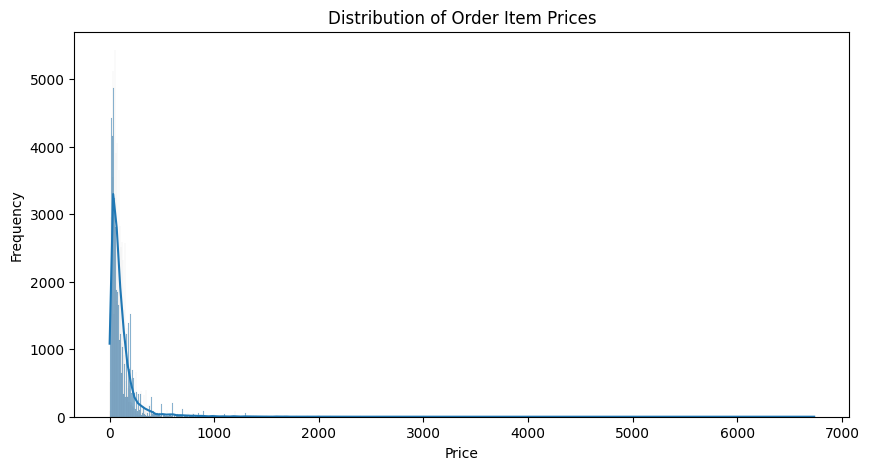

In [386]:
# melihat histogram variabel price dari orders_items_df
plt.figure(figsize=(10, 5))
plt.title('Distribution of Order Item Prices')
sns.histplot(orders_items_df['price'], kde=True)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


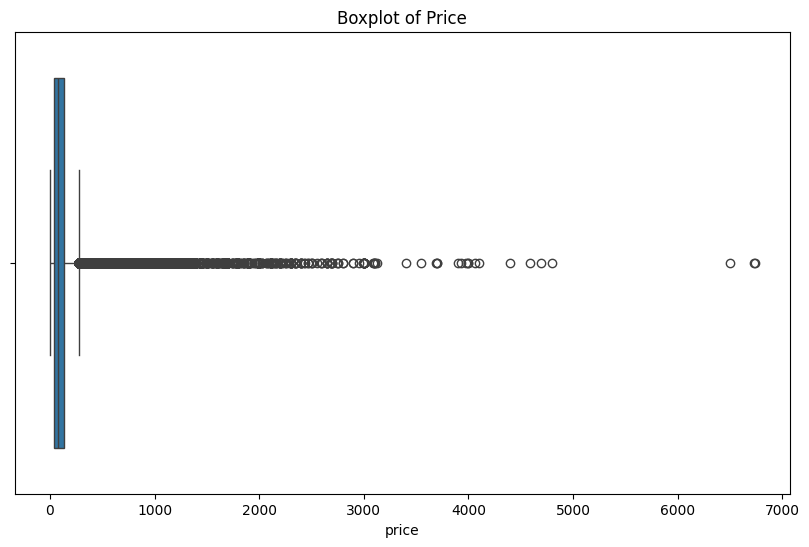

In [387]:
# melihat boxplot variabel price dari orders_items_df
plt.figure(figsize=(10, 6))
sns.boxplot(x=orders_items_df['price'])
plt.title('Boxplot of Price')
plt.show()


**Insight:**

Berdasarkan histogram dan boxplot di atas kita dapat mengambil kesimpulan bahwa distribusi data cenderung menceng kanan yang artinya terdapat nilai outlier di ekor kanan, hal ini menandakan terdapat produk-produk dengan harga tinggi.

Pada boxplot juga dapat dilihat adanya outlier yang berarti terdapat produk dengan harga tinggi. Outlier ini tetap dipertahankan karena untuk mempertahankan informasi yang ada.

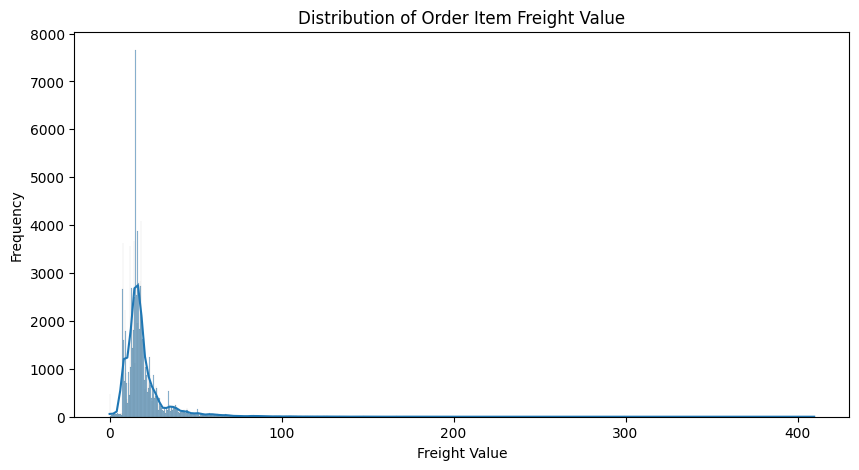

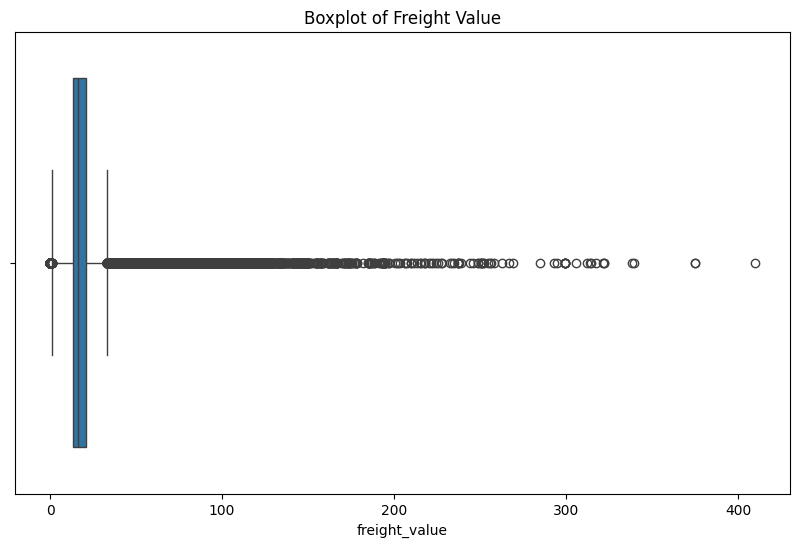

In [388]:
# melihat histogram variabel freight_value dari orders_items_df
plt.figure(figsize=(10, 5))
plt.title('Distribution of Order Item Freight Value')
sns.histplot(orders_items_df['freight_value'], kde=True)
plt.xlabel('Freight Value')
plt.ylabel('Frequency')
plt.show()

# melihat boxplot variabel freight_value dari orders_items_df
plt.figure(figsize=(10, 6))
sns.boxplot(x=orders_items_df['freight_value'])
plt.title('Boxplot of Freight Value')
plt.show()


In [389]:
# Menampilkan baris-baris di mana nilai freight_value = 0
zero_freight_value_df = orders_items_df[orders_items_df['freight_value'] == 0]
zero_freight_value_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
114,00404fa7a687c8c44ca69d42695aae73,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-15 04:31:26,99.9,0.0
258,00a870c6c06346e85335524935c600c0,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-05-14 00:14:29,69.9,0.0
483,011c899816ea29773525bd3322dbb6aa,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-07 05:30:45,99.9,0.0
508,012b3f6ab7776a8ab3443a4ad7bef2e6,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
509,012b3f6ab7776a8ab3443a4ad7bef2e6,2,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
...,...,...,...,...,...,...,...
111094,fc698f330ec7fb74859071cc6cb29772,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-04-25 02:31:57,53.9,0.0
111497,fd4907109f6bac23f07064af84bec02d,1,7a10781637204d8d10485c71a6108a2e,4869f7a5dfa277a7dca6462dcf3b52b2,2018-04-30 11:31:32,219.0,0.0
111649,fd95e4b85ebbb81853d4a6be3d61432b,1,53b36df67ebb7c41585e8d54d6772e08,4869f7a5dfa277a7dca6462dcf3b52b2,2018-05-04 11:10:31,106.9,0.0
112182,fee19a0dc7358b6962a611cecf6a37b4,1,f1c7f353075ce59d8a6f3cf58f419c9c,37be5a7c751166fbc5f8ccba4119e043,2017-09-07 22:06:31,195.0,0.0


**Insight:**

Berdasarkan histogram dan boxplot di atas kita dapat mengambil kesimpulan bahwa data berdistribusi right-skewness yang artinya sebagian besar data memiliki nilai freight_value yang kecil. Dapat dilihat juga terdapat data dengan nilai freight_value 0 hal ini dapat diindikasikan bahwa adanya campaign gratis ongkir dengan data yang memiliki nilai freight_value 0 sebanyak 383 data, sehingga data ini tidak dilakukan penangan seperti drop data atau yang lainnya.

#### **Mengatasi Missing Value**

In [390]:
# mengisi missing value pada kolom product_category_name dengan string
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


**Insight:**

Missing value pada kolom product_category_name berhasil ditangani dengan mengganti nilai null dengan string "unknown"

In [391]:
# Membuat DataFrame baru dengan data "unknown"
new_row = pd.DataFrame({'product_category_name': ['unknown'], 'product_category_name_english': ['unknown']})

# Menambahkan baris baru ke product_category_df
product_category_df = pd.concat([product_category_df, new_row], ignore_index=True)

product_category_df.tail()  # Untuk melihat baris terakhir, termasuk yang baru ditambahkan

,product_category_name,product_category_name_english
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes
70,seguros_e_servicos,security_and_services
71,unknown,unknown


Mengatasi missing value pada variabel numerik dengan melihat distribusi hortogramnya terlebih dahulu.
Variabel numeriknya yaitu:
product_name_lenght, product_description_lenght, and product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm

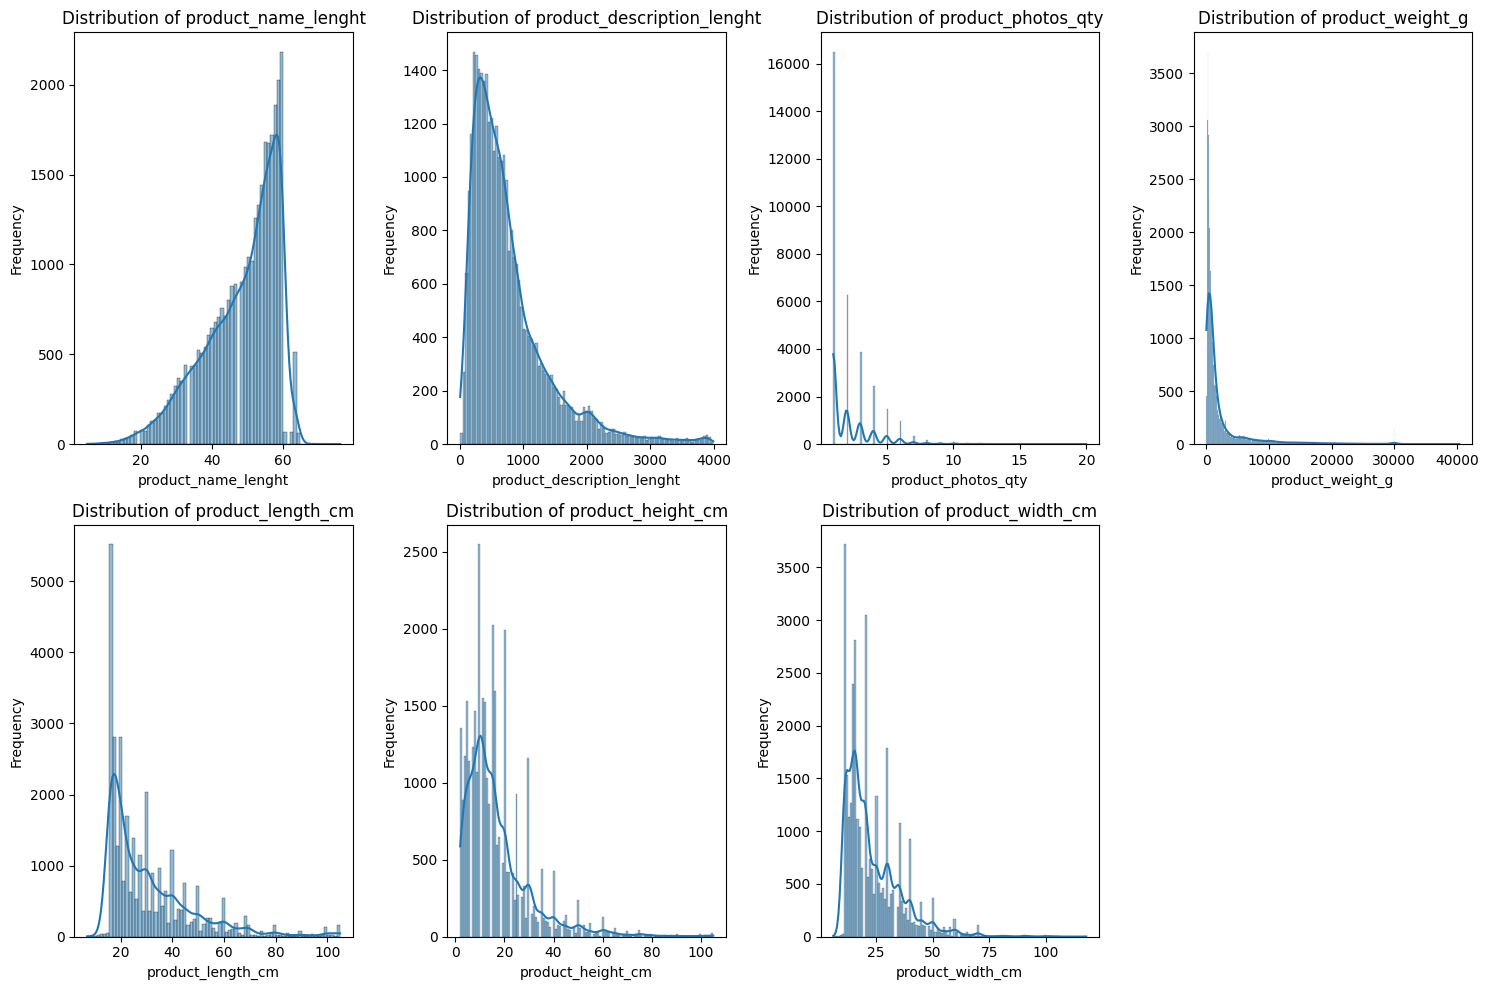

In [392]:
# mengatasi missing value untuk variabel numerik pada products_df
# melihat distribusi histogram

# Create histograms for numerical variables
numerical_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

# Calculate the number of rows needed
num_rows = int(np.ceil(len(numerical_cols) / 4))

plt.figure(figsize=(15, num_rows * 5))  # Adjust figure size based on rows

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 4, i + 1)  # Create subplots in rows of 4
    sns.histplot(products_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()  # Adjust subplot params for a tight layout
plt.show()

**Insight:**

Berdasarkan histogram dari variabel numerik di atas dapat disimpulkan bahwa terdapat kemencengan (skewness) pada distribusi datanya, sehingga penanganan missing value untuk variabel tersebut yaitu diimputasi dengan nilai median.

In [393]:
# mengisi missing value pada variabel numerik dengan median
for col in ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products_df[col] = products_df[col].fillna(products_df[col].median())

# Verify if missing values are filled
print(products_df.isna().sum())

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


**Insight:**

Missing value pada kolom variabel numerik berhasil ditangani dengan imputasi nilai median.

## Exploratory Data Analysis (EDA)

In [394]:
# menggabungkan data
df = pd.merge(orders_items_df, products_df, on='product_id')

# Gabungkan df dengan product_category_df berdasarkan 'product_category_name'
df = pd.merge(df, product_category_df, on='product_category_name', how='left')

df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


### Explore Data

In [395]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  datetime64[ns]
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   product_category_name          112650 non-null  object        
 8   product_name_lenght            112650 non-null  float64       
 9   product_description_lenght     112650 non-null  float64       
 10  product_photos_qty             112650 non-null  float64       
 11  

In [396]:
# Menampilkan data yang kosong pada kolom 'product_category_name_english'
missing_data = df[df['product_category_name_english'].isna()]
missing_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
3228,0745fd0c5e5bd55f752798a152b1d04b,1,a4756663d007b0cd1af865754d08d968,7aa538dd6e114e503a2e6154ea352253,2018-08-23 04:30:19,83.9,19.78,portateis_cozinha_e_preparadores_de_alimentos,60.0,1304.0,4.0,650.0,22.0,6.0,14.0,NaN
12976,1d7542bb5262913fe0516f7943b69a58,1,6727051471a0fc4a0e7737b57bff2549,1961c3e1272bfeceb05d0b78b5bbfdaf,2018-08-01 23:45:09,219.0,9.69,pc_gamer,60.0,1532.0,3.0,650.0,16.0,22.0,20.0,NaN
12977,1d7542bb5262913fe0516f7943b69a58,2,6727051471a0fc4a0e7737b57bff2549,1961c3e1272bfeceb05d0b78b5bbfdaf,2018-08-01 23:45:09,219.0,9.69,pc_gamer,60.0,1532.0,3.0,650.0,16.0,22.0,20.0,NaN
13025,1d911134e95ec6f299e80fe19b5b88c5,1,cb9d764f38ee4d0c00af64d5c388f837,ea1776927851da2532aa70d6a32c095a,2018-08-09 22:35:17,34.9,15.34,portateis_cozinha_e_preparadores_de_alimentos,57.0,306.0,1.0,625.0,28.0,27.0,24.0,NaN
18629,2ad4df0af7a71d632dccc0129bee3268,1,dbe520fb381ad695a7e1f2807d20c765,1961c3e1272bfeceb05d0b78b5bbfdaf,2018-08-03 16:44:57,239.0,10.42,pc_gamer,60.0,840.0,6.0,800.0,18.0,22.0,22.0,NaN


In [397]:
# Use square brackets and boolean indexing to select the row where 'product_category_name' is 'pc_gamer'
print(product_category_df[product_category_df['product_category_name'] == 'pc_gamer'])

Empty DataFrame
Columns: [product_category_name, product_category_name_english]
Index: []


Berdasarkan merging data di atas terdapat missing value karena terdapat product category name yang tidak memiliki data translationnya.

In [398]:
df.describe()

,order_item_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,112650.000000,112650,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320,48.807625,785.122548,2.192499,2093.449356,30.152845,16.593191,22.996067
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000,43.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000,57.000000,981.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000
std,0.705124,NaN,183.633928,15.806405,9.957478,647.881840,1.715141,3751.338501,16.152290,13.442486,11.706394


Berdasarkan statsitika deskriptif di atas kita dapat mengambil kesimpulan bahwa rata-rata harga dari produk yang terjual sebesar 74,99 dengan rata-rata biaya pengiriman sebesar 16,26.

In [399]:
# Analisis jumlah seller
seller_counts = df['seller_id'].value_counts().reset_index()
print(f"Jumlah seller yang memiliki produk terjual: {len(seller_counts)}")

Jumlah seller yang memiliki produk terjual: 3095


**Insight**

Berdasarkan analisis yang telah dilakukan, kita dapat mengambil kesimpulan bahwa:
- Jumlah seller yang memiliki produk terjual sebanyak 3095, hal ini menunjukkan bahwa jumlah penjual tergolong besar sehingga persaingan dalam penjualan barang dapat dikategorikan cukup ketat, namun dengan adanya penjual yang banyak memberikan pelanggan lebih banyak pilihan produk dengan berbagai harga dan kualitas.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang memiliki volume penjualan tertinggi, dan apa implikasinya terhadap strategi bisnis?

<ipython-input-400-51eba5968be8>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_counts.head(10), x='num_products', y='product_category', palette='magma')


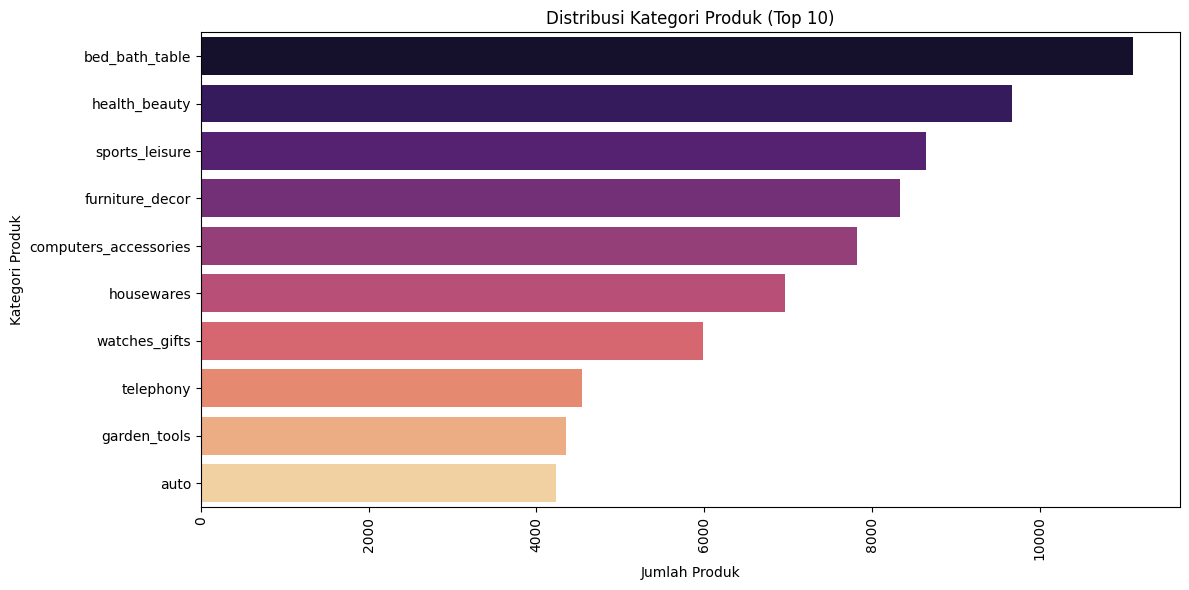

In [400]:
# Hitung jumlah produk per kategori (menggunakan product_category_name_english)
product_counts = df['product_category_name_english'].value_counts().reset_index()
product_counts.columns = ['product_category', 'num_products']

# Plot distribusi kategori produk
plt.figure(figsize=(12, 6))
sns.barplot(data=product_counts.head(10), x='num_products', y='product_category', palette='magma')
plt.xlabel('Jumlah Produk')
plt.ylabel('Kategori Produk')
plt.title('Distribusi Kategori Produk (Top 10)')
plt.xticks(rotation=90)  # Rotasi label sumbu x agar terbaca
plt.tight_layout()  # Sesuaikan layout agar label tidak terpotong
plt.show()

### Pertanyaan 2: Bagaimana pola tren pengiriman barang per bulan?

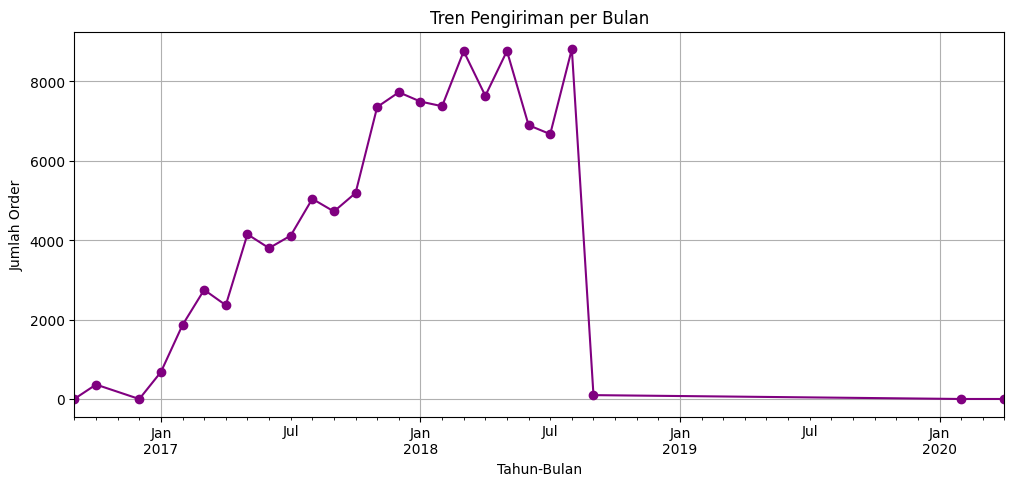

In [401]:
# Analisis Tren Waktu

df["year_month"] = df["shipping_limit_date"].dt.to_period("M")

# Plot tren pengiriman per bulan
plt.figure(figsize=(12, 5))
df["year_month"].value_counts().sort_index().plot(kind="line", marker="o", color='purple')
plt.title("Tren Pengiriman per Bulan")
plt.xlabel("Tahun-Bulan")
plt.ylabel("Jumlah Order")
plt.grid()
plt.show()

**Insight:**
- Berdasarkan analisis distribusi kategori produk dengan volume penjualan tertinggi (Top 10), kategori yang paling laris terjual adalah bed bath table, health beauty, sports leisure, computers accessories, housewares, watches gifts, telephony, dan garden tools. Hal ini menunjukkan bahwa produk-produk dalam kategori tersebut memiliki permintaan yang lebih tinggi dibandingkan kategori lainnya.
Implikasinya, bisnis dapat meningkatkan stok, memperbaiki strategi pemasaran, serta mengoptimalkan rantai pasokan untuk kategori produk yang memiliki permintaan tinggi guna memaksimalkan keuntungan dan kepuasan pelanggan.
- Berdasarkan grafik runtun waktu di atas kita dapat menyimpulkan bahwa dari januari 2017 hingga agustus 2018 pengiriman produk yang terjual mengalami peningkatan, namun pada september hingga januari 2020 pengiriman mengalami penurunan drastis hingga ke angka 0.

## Analisis Lanjutan (Opsional)

#### Segmentasi Produk secara Manual

In [402]:
# Definisikan kategori berdasarkan harga
def categorize_price(price):
    if price < 50:
        return "Murah"
    elif 50 <= price < 200:
        return "Menengah"
    else:
        return "Mahal"

# Definisikan kategori berdasarkan biaya pengiriman
def categorize_freight(freight):
    if freight < 10:
        return "Murah"
    elif 10 <= freight < 50:
        return "Sedang"
    else:
        return "Mahal"

# Terapkan kategori
df['Kategori_Harga'] = df['price'].apply(categorize_price)
df['Kategori_Pengiriman'] = df['freight_value'].apply(categorize_freight)

# Tampilkan hasil
print(df[['price', 'Kategori_Harga', 'freight_value', 'Kategori_Pengiriman']].head())

    price Kategori_Harga  freight_value Kategori_Pengiriman
0   58.90       Menengah          13.29              Sedang
1  239.90          Mahal          19.93              Sedang
2  199.00       Menengah          17.87              Sedang
3   12.99          Murah          12.79              Sedang
4  199.90       Menengah          18.14              Sedang


**Insight:**

Berdasarkan output di atas, data ini menunjukkan harga produk dan biaya pengiriman (freight value) yang telah dikelompokkan ke dalam kategori tertentu. Berikut adalah analisisnya:

1. Kategori Harga

- Produk dikelompokkan ke dalam tiga kategori harga: Murah, Menengah, dan Mahal.
Contohnya, produk dengan harga 12.99 masuk dalam kategori Murah, sementara produk dengan harga 239.90 dikategorikan sebagai Mahal.
Rentang harga ini menunjukkan adanya variasi produk yang dapat menjangkau berbagai segmen pasar, mulai dari produk yang terjangkau hingga produk premium.
2. Kategori Pengiriman

- Semua produk dalam sampel ini memiliki biaya pengiriman yang masuk dalam kategori Sedang.
Biaya pengiriman berkisar antara 12.79 hingga 19.93, yang menunjukkan adanya perbedaan kecil dalam tarif pengiriman meskipun harga produk berbeda.
Faktor yang mempengaruhi biaya pengiriman bisa termasuk berat produk, dimensi, dan lokasi pengiriman.

#### Segmentasi Pelanggan Berdasarkan RFM Manual

In [403]:
# Hitung RFM secara manual
snapshot_date = df['shipping_limit_date'].max()  # Tanggal terakhir dalam dataset
rfm = df.groupby('order_id').agg({
    'shipping_limit_date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'count',  # Frequency
    'price': 'sum'  # Monetary
}).rename(columns={'shipping_limit_date': 'Recency', 'order_id': 'Frequency', 'price': 'Monetary'})

# Definisikan kategori Recency
def categorize_recency(days):
    if days <= 30:
        return "Pelanggan Baru"
    elif 30 < days <= 90:
        return "Pelanggan Sedang"
    else:
        return "Pelanggan Lama"

# Definisikan kategori Frequency
def categorize_frequency(freq):
    if freq == 1:
        return "Jarang Belanja"
    elif 2 <= freq <= 5:
        return "Rutin Belanja"
    else:
        return "Sering Belanja"

# Definisikan kategori Monetary
def categorize_monetary(money):
    if money < 100:
        return "Pembelanja Kecil"
    elif 100 <= money < 500:
        return "Pembelanja Sedang"
    else:
        return "Pembelanja Besar"

# Terapkan kategori ke setiap pelanggan
rfm['Kategori_Recency'] = rfm['Recency'].apply(categorize_recency)
rfm['Kategori_Frequency'] = rfm['Frequency'].apply(categorize_frequency)
rfm['Kategori_Monetary'] = rfm['Monetary'].apply(categorize_monetary)

# Tampilkan hasil
print(rfm.head())


                                  Recency  Frequency  Monetary  \
order_id                                                         
00010242fe8c5a6d1ba2dd792cb16214      933          1     58.90   
00018f77f2f0320c557190d7a144bdd3     1072          1    239.90   
000229ec398224ef6ca0657da4fc703e      812          1    199.00   
00024acbcdf0a6daa1e931b038114c75      603          1     12.99   
00042b26cf59d7ce69dfabb4e55b4fd9     1151          1    199.90   

                                 Kategori_Recency Kategori_Frequency  \
order_id                                                               
00010242fe8c5a6d1ba2dd792cb16214   Pelanggan Lama     Jarang Belanja   
00018f77f2f0320c557190d7a144bdd3   Pelanggan Lama     Jarang Belanja   
000229ec398224ef6ca0657da4fc703e   Pelanggan Lama     Jarang Belanja   
00024acbcdf0a6daa1e931b038114c75   Pelanggan Lama     Jarang Belanja   
00042b26cf59d7ce69dfabb4e55b4fd9   Pelanggan Lama     Jarang Belanja   

                                

**Insight:**

Berdasarkan output di atas, dataset ini menampilkan hasil analisis RFM (Recency, Frequency, Monetary) yang digunakan untuk segmentasi pelanggan berdasarkan pola pembelian mereka. Berikut adalah penjelasan dari masing-masing variabel:

- Recency (R) → Mengukur seberapa lama pelanggan terakhir kali melakukan pembelian. Nilai recency yang tinggi menunjukkan pelanggan sudah lama tidak bertransaksi (Pelanggan Lama).
Dalam data ini, semua pelanggan masuk dalam kategori Pelanggan Lama, dengan nilai recency antara 603 hingga 1151 hari.
- Frequency (F) → Mengukur seberapa sering pelanggan melakukan pembelian. Semua pelanggan dalam sampel memiliki frequency = 1, sehingga masuk dalam kategori Jarang Belanja.
Ini menunjukkan bahwa pelanggan ini hanya melakukan satu kali transaksi dalam periode yang diamati.
- Monetary (M) → Mengukur total jumlah uang yang dihabiskan oleh pelanggan. Kategori Pembelanja Kecil artinya menghabiskan sedikit uang, seperti pelanggan dengan total belanja 58.90 atau 12.99.
Kategori Pembelanja Sedang artinya menghabiskan jumlah yang lebih besar, misalnya 199.90 atau 239.90.

## Conclusion

- Berdasarkan analisis distribusi kategori produk dengan volume penjualan tertinggi (Top 10), kategori yang paling laris terjual adalah bed bath table, health beauty, sports leisure, computers accessories, housewares, watches gifts, telephony, dan garden tools. Hal ini menunjukkan bahwa produk-produk dalam kategori tersebut memiliki permintaan yang lebih tinggi dibandingkan kategori lainnya.
Implikasinya, bisnis dapat meningkatkan stok, memperbaiki strategi pemasaran, serta mengoptimalkan rantai pasokan untuk kategori produk yang memiliki permintaan tinggi guna memaksimalkan keuntungan dan kepuasan pelanggan.
- Berdasarkan grafik runtun waktu di atas kita dapat menyimpulkan bahwa dari januari 2017 hingga agustus 2018 pengiriman produk yang terjual mengalami peningkatan, namun pada september hingga januari 2020 pengiriman mengalami penurunan drastis hingga ke angka 0.
- Berdasarkan segmentasi produk diperoleh kesimpulan bahwa harga produk memiliki variasi yang cukup signifikan, yang memungkinkan strategi pemasaran berbasis segmen pelanggan. Biaya pengiriman relatif stabil dalam kategori "Sedang", yang bisa menunjukkan adanya standar penghitungan biaya pengiriman oleh penyedia jasa logistik.
- Berdasarkan segmentasi pelanggan diperoleh kesimpulan bahwa:
1. Mayoritas pelanggan dalam data ini tergolong sebagai pelanggan lama dan jarang berbelanja. Mereka hanya melakukan satu kali transaksi dalam periode yang diamati, sehingga kemungkinan loyalitas mereka rendah.
2. Kategori Monetary menunjukkan bahwa ada variasi dalam jumlah uang yang dibelanjakan, dengan beberapa pelanggan menghabiskan lebih banyak dibanding yang lain.
3. Strategi Retensi Pelanggan dibutuhkan
untuk meningkatkan Frequency, perusahaan dapat menawarkan program loyalitas, diskon untuk pembelian berikutnya, atau promosi eksklusif bagi pelanggan lama.
Untuk mengonversi Pelanggan Lama menjadi pelanggan aktif, dapat dilakukan kampanye pemasaran ulang (retargeting) menggunakan email atau media sosial untuk mengingatkan mereka tentang produk yang mereka sukai.